# Dataset exploration

This notebook:
- explores the multilingual natural-language inference data
- reuses the project's loading and schema-validation helpers (watson_dataset_config, watson_dataset_helpers)

After data exploration, we can then choose a model and validation strategy. That will be done in a separate notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from watson_dataset_config import LABEL_NAMES
from watson_dataset_helpers import (
    build_dataset_overview,
    load_datasets,
    validate_dataset_columns,
)

pd.set_option("display.max_colwidth", 180)
plt.style.use("seaborn-v0_8-whitegrid")

## Load and validate the data

In [2]:
datasets = load_datasets()
validate_dataset_columns(datasets)

train = datasets["train"].copy()
test = datasets["test"].copy()
submission = datasets["sample_submission"].copy()

build_dataset_overview(datasets)

Kaggle files already present; using: (project_root)/data/raw


,rows,columns,missing_values,duplicate_ids
dataset,,,,
train,12120,6,0,0
test,5195,5,0,0
sample_submission,5195,2,0,0


In [3]:
display(train.head())
display(test.head())
display(submission.head())

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulating the interim rules.,The rules developed in the interim were put together with these comments in mind.,en,English,0
1,5b72532a0b,"These are issues that we wrestle with in practice groups of law firms, she said.",Practice groups are not permitted to work on these issues.,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une différence énorme dans ce que j'essaye de faire.,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves like somebody grown uh say my age you know yeah,They can't defend themselves because of their age.,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสดงออกและได้เล่นหลายบทบาทไปพร้อมกัน ๆ อาจช่วยให้เด็กจับความคล้ายคลึงและความแตกต่างระหว่างผู้คนในด้านความปรารถนา ความเชื่อ และความรู้...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


,id,premise,hypothesis,lang_abv,language
0,c6d58c3f69,بکس، کیسی، راہیل، یسعیاہ، کیلی، کیلی، اور کولمبین ہائی اسکول کے دوسرے طلبا کے نام سے بکسوں کو نشان زد کیا جائے گا جس نے اس سال پہلے اپنی زندگی کھو دی,"کیسی کے لئے کوئی یادگار نہیں ہوگا, کولمین ہائی اسکول کے طالب علموں میں سے ایک جو مر گیا.",ur,Urdu
1,cefcc82292,هذا هو ما تم نصحنا به.,عندما يتم إخبارهم بما يجب عليهم فعله ، فشلت الإدارة في السماح لنا بالدخول إلى الأسرار التجارية.,ar,Arabic
2,e98005252c,et cela est en grande partie dû au fait que les mères prennent de la drogue,Les mères se droguent.,fr,French
3,58518c10ba,与城市及其他公民及社区组织代表就IMA的艺术发展进行对话&amp,IMA与其他组织合作，因为它们都依靠共享资金。,zh,Chinese
4,c32b0d16df,Она все еще была там.,"Мы думали, что она ушла, однако, она осталась.",ru,Russian


,id,prediction
0,c6d58c3f69,1
1,cefcc82292,1
2,e98005252c,1
3,58518c10ba,1
4,c32b0d16df,1


### Initial observations

Dataset shape and schema:
- train: 12120 x 6
- test: 5195 x 5 (same as train minus the label)
- submission: 5195 x 2 (just id and label)

Missing or unexpected values:
- no missing values, we will explore further for unexpected/strange values

## Class balance

In [4]:
labels_by_language = pd.crosstab(
    train["language"],
    train["label"].map(LABEL_NAMES),
)
label_proportions_by_language = labels_by_language.div(
    labels_by_language.sum(axis=1), axis=0
)

display(labels_by_language)
display(label_proportions_by_language.round(3))

label,contradiction,entailment,neutral
language,,,
Arabic,148,124,129
Bulgarian,108,123,111
Chinese,125,140,146
English,2277,2427,2166
French,128,133,129
German,127,108,116
Greek,125,120,127
Hindi,137,125,112
Russian,120,132,124


label,contradiction,entailment,neutral
language,,,
Arabic,0.369,0.309,0.322
Bulgarian,0.316,0.360,0.325
Chinese,0.304,0.341,0.355
English,0.331,0.353,0.315
French,0.328,0.341,0.331
German,0.362,0.308,0.330
Greek,0.336,0.323,0.341
Hindi,0.366,0.334,0.299
Russian,0.319,0.351,0.330


In [5]:
label_counts = (
    train["label"]
    .value_counts()
    .sort_index()
    .rename(index=LABEL_NAMES)
    .rename("count")
    .to_frame()
)
label_counts["proportion"] = label_counts["count"] / len(train)
label_counts

,count,proportion
label,,
entailment,4176,0.344554
neutral,3880,0.320132
contradiction,4064,0.335314


In [6]:
labels_by_language = pd.crosstab(
    train["language"],
    train["label"].map(LABEL_NAMES),
)
label_proportions_by_language = labels_by_language.div(
    labels_by_language.sum(axis=1), axis=0
)

display(labels_by_language)
display(label_proportions_by_language.round(3))

label,contradiction,entailment,neutral
language,,,
Arabic,148,124,129
Bulgarian,108,123,111
Chinese,125,140,146
English,2277,2427,2166
French,128,133,129
German,127,108,116
Greek,125,120,127
Hindi,137,125,112
Russian,120,132,124


label,contradiction,entailment,neutral
language,,,
Arabic,0.369,0.309,0.322
Bulgarian,0.316,0.360,0.325
Chinese,0.304,0.341,0.355
English,0.331,0.353,0.315
French,0.328,0.341,0.331
German,0.362,0.308,0.330
Greek,0.336,0.323,0.341
Hindi,0.366,0.334,0.299
Russian,0.319,0.351,0.330


## Language coverage

In [7]:
language_counts = pd.concat(
    [
        train["language"].value_counts().rename("train"),
        test["language"].value_counts().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)
language_counts["train_proportion"] = language_counts["train"] / len(train)
language_counts["test_proportion"] = language_counts["test"] / len(test)
language_counts.sort_values("train", ascending=False)

,train,test,train_proportion,test_proportion
language,,,,
English,6870,2945,0.566832,0.566891
Chinese,411,151,0.033911,0.029066
Arabic,401,159,0.033086,0.030606
French,390,157,0.032178,0.030221
Swahili,385,172,0.031766,0.033109
Urdu,381,168,0.031436,0.032339
Vietnamese,379,145,0.031271,0.027911
Russian,376,172,0.031023,0.033109
Hindi,374,150,0.030858,0.028874


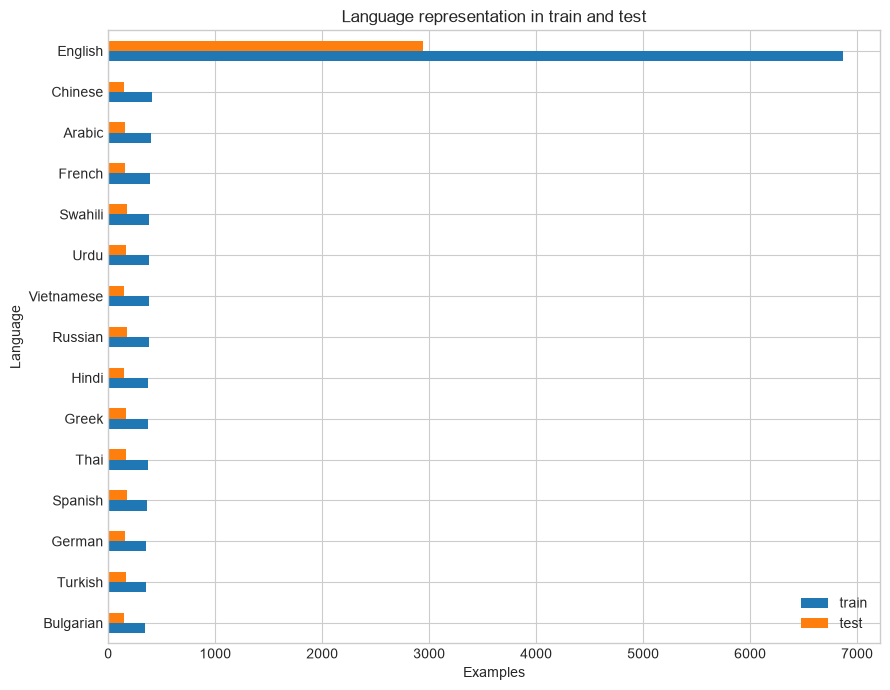

In [8]:
language_counts[["train", "test"]].sort_values("train").plot.barh(
    figsize=(9, 7),
    title="Language representation in train and test",
)
plt.xlabel("Examples")
plt.ylabel("Language")
plt.tight_layout()

### Observations about Language and Class Label Distribution
1. The language distribution exploration shows that there are many more examples in English than in any other language. It remains to be seen if this is an actual issue in terms of learning for the model.
2. Although English examples are more prevalent, at least the test and training sets have similar language distributions. It appears the dataset preparation included stratification (thankfully).
3. Contradiction, entailment, and neutral each account for roughly one third of the training set overall, and the class labels are reasonably balanced within each language.

## Text lengths

Character counts are a first-pass description. They are not token counts, and their meaning varies across languages. A single character in one language may express much more than one character does in another language.

In [9]:
TEXT_COLUMNS = ["premise", "hypothesis"]

for frame in (train, test):
    for column in TEXT_COLUMNS:
        frame[f"{column}_chars"] = frame[column].str.len()
        frame[f"{column}_words"] = frame[column].str.split().str.len()

length_columns = [
    "premise_chars",
    "hypothesis_chars",
    "premise_words",
    "hypothesis_words",
]
train[length_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(1)

,premise_chars,hypothesis_chars,premise_words,hypothesis_words
count,12120.0,12120.0,12120.0,12120.0
mean,107.4,53.9,18.0,9.2
std,71.1,25.3,12.9,4.7
min,4.0,4.0,1.0,1.0
1%,13.0,11.0,1.0,1.0
5%,23.0,19.0,2.0,1.0
50%,96.0,51.0,16.0,9.0
95%,226.0,99.0,39.0,17.0
99%,319.8,133.0,54.8,23.0
max,967.0,276.0,196.0,46.0


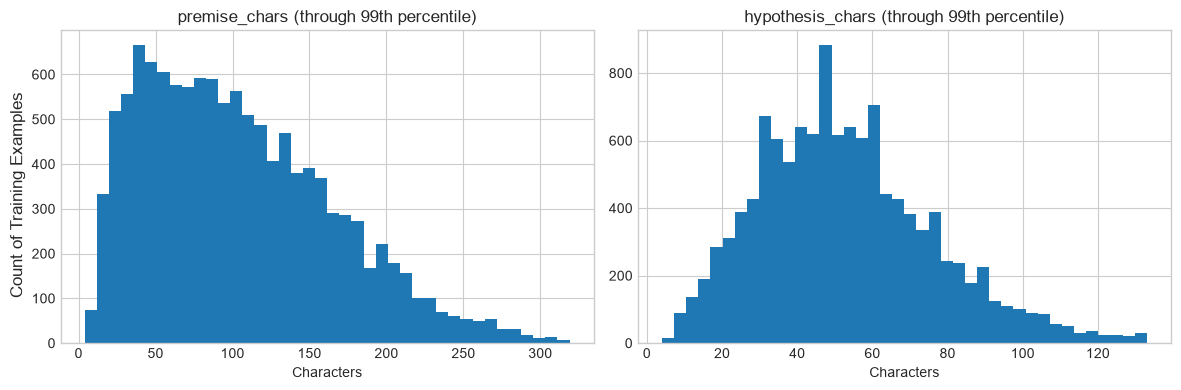

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for column, axis in zip(["premise_chars", "hypothesis_chars"], axes):
    upper_bound = train[column].quantile(0.99)
    train.loc[train[column] <= upper_bound, column].plot.hist(
        bins=40, ax=axis, title=f"{column} (through 99th percentile)"
    )
    axis.set_xlabel("Characters")
    axis.set_ylabel("")

fig.supylabel("Count of Training Examples")
plt.tight_layout()

In [11]:
lengths_by_language = train.groupby("language")[length_columns].agg(
    ["min", "median", "mean", "max"]
).round(1)
lengths_by_language

premise_chars                    hypothesis_chars               \
                     min median   mean  max              min median  mean   
language                                                                    
Arabic                18   83.0   90.2  220                9   40.0  43.0   
Bulgarian             14  108.5  112.3  303               10   53.0  55.6   
Chinese                4   32.0   33.4  101                5   15.0  16.2   
English                8   95.0  111.2  967                4   53.0  56.2   
French                21  113.5  119.7  281               11   57.0  61.3   
German                22  111.0  117.0  280               18   56.0  59.2   
Greek                 19  115.5  119.8  270               15   56.0  58.7   
Hindi                 23  100.0  105.9  300               12   51.5  54.0   
Russian               17  104.5  110.1  270               12   50.0  54.6   
Spanish               18  114.0  116.1  268               18   53.0  58.8   
Swahili               17   96.0  104.4  266               16   49.0  51.7   
Thai                   7   90.0   98.8  225               11   43.0  45.7   
Turkish               14   97.0  102.9  269               13   49.0  52.2   
Urdu                  19   99.0   98.7  231               14   47.0  50.5   
Vietnamese            14  109.0  112.7  272               17   52.0  55.4   

                premise_words                   hypothesis_words               \
            max           min median  mean  max              min median  mean   
language                                                                        
Arabic      159             3   15.0  16.1   40                2    7.0   7.8   
Bulgarian   181             2   17.0  17.9   39                2    9.0   9.0   
Chinese      46             1    1.0   1.3   13                1    1.0   1.1   
English     276             1   16.0  19.3  196                1    9.0   9.9   
French      153             3   19.0  19.8   44                2   10.0  10.3   
German      141             4   16.0  17.4   41                3    8.0   9.0   
Greek       153             3   18.0  18.8   44                2    9.0   9.3   
Hindi       133             4   20.0  21.1   47                2   10.0  11.0   
Russian     166             3   16.0  16.3   40                2    8.0   8.1   
Spanish     177             3   19.0  19.6   44                3    9.0   9.9   
Swahili     146             1   15.0  16.2   41                2    7.0   7.9   
Thai        129             1    3.0   4.0   21                1    1.0   1.6   
Turkish     135             2   13.0  13.8   34                2    7.0   7.0   
Urdu        145             3   21.0  21.3   45                3   10.0  11.2   
Vietnamese  159             3   24.0  25.2   61                4   12.0  12.6   

                
           max  
language        
Arabic      28  
Bulgarian   31  
Chinese      5  
English     46  
French      25  
German      24  
Greek       23  
Hindi       28  
Russian     23  
Spanish     34  
Swahili     23  
Thai         7  
Turkish     18  
Urdu        32  
Vietnamese  34

## Very short text audit
- Quantify examples that use fewer than (specified number threshold) characters.
- Make threshold adjustable
- Python's `str.len()` counts Unicode code points; a short count does not necessarily mean little semantic content, especially across languages.

In [12]:
SHORT_TEXT_THRESHOLD = 10

short_premise = train["premise_chars"] < SHORT_TEXT_THRESHOLD
short_hypothesis = train["hypothesis_chars"] < SHORT_TEXT_THRESHOLD

short_text_summary = pd.Series(
    {
        "short premise": short_premise.sum(),
        "short hypothesis": short_hypothesis.sum(),
        "either is short": (short_premise | short_hypothesis).sum(),
        "both are short": (short_premise & short_hypothesis).sum(),
    },
    name="examples",
).to_frame()
short_text_summary["proportion_of_train"] = (
    short_text_summary["examples"] / len(train)
)
short_text_summary

,examples,proportion_of_train
short premise,38,0.003135
short hypothesis,71,0.005858
either is short,97,0.008003
both are short,12,0.000990


In [13]:
short_counts_by_language = (
    train.assign(
        short_premise=short_premise,
        short_hypothesis=short_hypothesis,
        either_short=short_premise | short_hypothesis,
        both_short=short_premise & short_hypothesis,
    )
    .groupby("language")
    .agg(
        examples=("id", "size"),
        short_premises=("short_premise", "sum"),
        short_hypotheses=("short_hypothesis", "sum"),
        either_short=("either_short", "sum"),
        both_short=("both_short", "sum"),
    )
)
short_counts_by_language["either_short_rate"] = (
    short_counts_by_language["either_short"]
    / short_counts_by_language["examples"]
)
short_counts_by_language.sort_values("either_short_rate", ascending=False)

,examples,short_premises,short_hypotheses,either_short,both_short,either_short_rate
language,,,,,,
Chinese,411,12,51,57,6,0.138686
English,6870,25,18,37,6,0.005386
Arabic,401,0,2,2,0,0.004988
Thai,371,1,0,1,0,0.002695
Bulgarian,342,0,0,0,0,0.000000
French,390,0,0,0,0,0.000000
German,351,0,0,0,0,0.000000
Greek,372,0,0,0,0,0.000000
Hindi,374,0,0,0,0,0.000000


In [14]:
short_text_candidates = (
    train.loc[
        short_premise | short_hypothesis,
        [
            "id",
            "language",
            "label",
            "premise_chars",
            "hypothesis_chars",
            "premise",
            "hypothesis",
        ],
    ]
    .assign(label_name=lambda frame: frame["label"].map(LABEL_NAMES))
    .sort_values(["premise_chars", "hypothesis_chars"])
)
short_text_candidates

,id,language,label,premise_chars,hypothesis_chars,premise,hypothesis,label_name
2459,9265594243,Chinese,0,4,8,彼此阻拦,是的，阻碍彼此。,entailment
6509,4dc5366742,Chinese,0,6,10,这就是时势。,当时有一种情绪状态。,entailment
6461,6b68e2580e,Chinese,0,7,6,当我长大时，嗯,我正在长大。,entailment
10625,3cb4ea9755,Chinese,0,7,7,大约嗯二十分钟,大约二十分钟。,entailment
10048,28c05af903,Chinese,0,7,10,很高兴和你聊天,这是一次愉快的谈话。,entailment
...,...,...,...,...,...,...,...,...
3285,f5efda1426,Chinese,2,54,8,然后，另一位之前已经参观过的代表又拜访了新的供应商，解开了迷惑并且一起探讨了在索取样品上可能遇到的任何问题。,我们从未拜访过。,contradiction
9698,2cb738f09e,Chinese,2,57,9,结果，他的薪金提高了，他的其他津贴也大大增加了，从大约465美元增加到每月3925美元，直到2000年12月为止。,他的月收入降低了。,contradiction
4854,c720c9a569,Chinese,0,60,6,他来自希腊，他来自希腊的一个叫Tokalleka的小村庄，我相信他是在1969或1970年来美国的，并且他很快就结婚了。,他是希腊人。,entailment
6995,e5c51b79b0,Arabic,0,91,9,تدرك واندا تمامًا كأي أم الاحتمالات الجديدة التي تنتج عنك، وتعتبرها شيء رائع جدير بالمعرفة.,واندا أم.,entailment


Change `SHORT_TEXT_THRESHOLD` above to widen or narrow the audit. The candidate table remains a DataFrame, so it can also be filtered by language, label, or either length column before displaying selected rows.

### Observation about examples with fewer characters:
I translated some of these premises and hypotheses to English. It's actually pretty amazing how some languages can convey so much information in so few characters.

## Duplicate and conflicting examples

In [15]:
pair_columns = ["premise", "hypothesis"]
duplicate_pair_mask = train.duplicated(pair_columns, keep=False)
duplicate_pairs = train.loc[duplicate_pair_mask].sort_values(pair_columns)

conflicting_pairs = (
    train.groupby(pair_columns, dropna=False)["label"]
    .nunique()
    .loc[lambda counts: counts > 1]
)

pd.Series(
    {
        "rows belonging to duplicated pairs": len(duplicate_pairs),
        "unique duplicated pairs": train.loc[duplicate_pair_mask, pair_columns].drop_duplicates().shape[0],
        "pairs with conflicting labels": len(conflicting_pairs),
    }
)

rows belonging to duplicated pairs    0
unique duplicated pairs               0
pairs with conflicting labels         0
dtype: int64

In [16]:
duplicate_pairs[["id", "language", "label", *pair_columns]]

,id,language,label,premise,hypothesis


## Train/test text overlap

Exact overlap can affect how we interpret validation and test performance. This is a diagnostic only; test labels remain unknown.

In [17]:
train_pairs = pd.MultiIndex.from_frame(train[pair_columns])
test_pairs = pd.MultiIndex.from_frame(test[pair_columns])

overlap_summary = pd.Series(
    {
        "test rows that have the same premise/hypothesis pair as in train": test_pairs.isin(train_pairs).sum(),
        "test rows with premise seen in train": test["premise"].isin(train["premise"]).sum(),
        "test rows with hypothesis seen in train": test["hypothesis"].isin(train["hypothesis"]).sum(),
    }
)
overlap_summary

test rows that have the same premise/hypothesis pair as in train       0
test rows with premise seen in train                                2868
test rows with hypothesis seen in train                                0
dtype: int64

In [18]:
test.loc[
    test_pairs.isin(train_pairs),
    ["id", "language", "premise", "hypothesis"],
]

,id,language,premise,hypothesis


### Observations about train/test text overlap

- 2,868 of the 5,195 test rows (about 55%) have a premise that also appears in training!!! More than half of the test examples therefore pair a familiar premise with a new hypothesis.
- no complete premise–hypothesis pairs repeat across the two sets (so that's good)
- no test hypotheses appear among the training hypotheses. (so that's good, too)

This overlap raises a potential data leakage concern: test examples are not entirely independent of training at the premise level. However, shared premises alone do not establish label leakage, because the premise–hypothesis combinations are new and knowing a premise does not determine the label. Validation should distinguish performance on familiar premises from performance on unseen premises. To evaluate generalization to unseen premises, all examples sharing a premise should be kept in the same split.

## Data Leakage Mea Culpa and the Approach going forward

- I inspected the unlabeled test inputs during exploration and unexpectedly found that 2,868 of 5,195 test rows (about 55%) share a premise with training. This influenced my thinking about validation. OOPS! I hold myself to a strict standard: test-set knowledge should not guide development. Under that standard, I regard this as data leakage, even though I used no test labels.
- I cannot unlearn this observation, so I am being transparent and documenting it openly as a lesson and a reminder to be careful about what I inspect from the test set (no matter how seemingly benign).
- Data Leakage notwithstanding, I am still considering grouping by premise to evaluate generalization to unseen premises. Again, this is me steering the model development based on what I know about the test set... But I can't unlearn what I have snooped. Going forward, though, I will ground future model and validation decisions in the labeled training data ONLY and avoid further test-driven adjustments.
- It's ironic. After comparing test set data with train data, I thought I had found potential data leakage (i.e. some premises in the test set are present in the training data). But me snooping the test data was itself data leakage. I created the problem I was checking for!

# Summary

- No missing values were found. Labels are broadly balanced overall and within languages, while English is much more prevalent.
- Short texts can convey substantial meaning; character counts need context across languages.
- The documented overlap involves shared premises, with no repeated complete pairs or hypotheses. I regard my test snooping as leakage under my strict standard, despite using no test labels.
- I will ground further decisions in labeled training data. Premise grouping remains under consideration; I have not adopted a validation strategy.